# Clasificación de Enfermedades en Aguacate con VGG16
## Healthy, Scab, Anthracnose - Objetivo Accuracy ≥ 90%

## 1. Configuración e Imports

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import shutil
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Carga de Datos y Copia Local

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
csv_path = '/content/drive/MyDrive/MachineLearning2026/ProyectoMachineLearning/Avocado labels 1.csv'
drive_img_folder = '/content/drive/MyDrive/MachineLearning2026/ProyectoMachineLearning/ImagenesAguacate/'
local_img_folder = '/content/imagenes_aguacate/'

if not os.path.exists(local_img_folder):
    print("Copiando imágenes a local...")
    shutil.copytree(drive_img_folder, local_img_folder)
    print("Listo.")
else:
    print("Imágenes ya en local.")

df = pd.read_csv(csv_path)
df['image_path'] = df['Identification'].apply(lambda x: os.path.join(local_img_folder, x + '.jpg'))
df['exists'] = df['image_path'].apply(os.path.exists)
df = df[df['exists']].reset_index(drop=True)
print(f"Total imágenes válidas: {len(df)}")
df.head()

Copiando imágenes a local...
Listo.
Total imágenes válidas: 3983


,Identification,Condition,Healthy,Scab,Anthracnose,image_path,exists
0,Avocado 0001,Scab,0,1,0,/content/imagenes_aguacate/Avocado 0001.jpg,True
1,Avocado 0002,Scab,0,1,0,/content/imagenes_aguacate/Avocado 0002.jpg,True
2,Avocado 0003,Healthy,1,0,0,/content/imagenes_aguacate/Avocado 0003.jpg,True
3,Avocado 0004,Scab,0,1,0,/content/imagenes_aguacate/Avocado 0004.jpg,True
4,Avocado 0005,Anthracnose,0,0,1,/content/imagenes_aguacate/Avocado 0005.jpg,True


## 3. Preprocesamiento y División Estratificada

In [ ]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['Condition'])
class_names = le.classes_
print("Clases:", dict(zip(class_names, range(3))))

X = df['image_path'].values
y = df['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Clases: {'Anthracnose': 0, 'Healthy': 1, 'Scab': 2}
Train: 3186 | Val: 398 | Test: 399


## 4. Data Augmentation y Generadores (tamaño 224x224 para VGG16)

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    pd.DataFrame({'filename': X_train, 'class': y_train}),
    x_col='filename', y_col='class', target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='raw', shuffle=True
)

val_gen = val_test_datagen.flow_from_dataframe(
    pd.DataFrame({'filename': X_val, 'class': y_val}),
    x_col='filename', y_col='class', target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='raw', shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    pd.DataFrame({'filename': X_test, 'class': y_test}),
    x_col='filename', y_col='class', target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='raw', shuffle=False
)

print("Clases:", dict(zip(class_names, range(len(class_names)))))

Found 3186 validated image filenames.
Found 398 validated image filenames.
Found 399 validated image filenames.
Clases: {'Anthracnose': 0, 'Healthy': 1, 'Scab': 2}


## 5. Construcción del modelo con VGG16, regularización L2 y Dropout

In [ ]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,111,491 (57.65 MB)

 Trainable params: 395,779 (1.51 MB)

 Non-trainable params: 14,715,712 (56.14 MB)

## 6. Pesos de Clase (balance)

In [ ]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))
print("Pesos:", class_weight_dict)

Pesos: {np.int64(0): np.float64(1.2982885085574571), np.int64(1): np.float64(0.7526576895818569), np.int64(2): np.float64(1.109717868338558)}


## 7. Entrenamiento Fase 1 (solo cabeza)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)
checkpoint = ModelCheckpoint('best_model_vgg16.keras', monitor='val_accuracy', save_best_only=True, mode='max')

history1 = model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr, checkpoint],
    steps_per_epoch=len(X_train)//BATCH_SIZE,
    validation_steps=len(X_val)//BATCH_SIZE
)

Epoch 1/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 82s 668ms/step - accuracy: 0.5685 - loss: 1.7299 - val_accuracy: 0.5729 - val_loss: 1.7568 - learning_rate: 0.0010
Epoch 2/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.7188 - loss: 1.4656 - val_accuracy: 0.5755 - val_loss: 1.7561 - learning_rate: 0.0010
Epoch 3/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 55s 556ms/step - accuracy: 0.6449 - loss: 1.4946 - val_accuracy: 0.6823 - val_loss: 1.6276 - learning_rate: 0.0010
Epoch 4/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6875 - loss: 1.5703 - val_accuracy: 0.6536 - val_loss: 1.6293 - learning_rate: 0.0010
Epoch 5/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 55s 556ms/step - accuracy: 0.6839 - loss: 1.3751 - val_accuracy: 0.7005 - val_loss: 1.4407 - learning_rate: 0.0010
Epoch 6/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.4688 - loss: 1.5938 - val_accuracy: 0.7031 - val_loss: 1.4393 - learning_rate: 0.0010
Epoch 7/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 55s 554ms/step - accuracy: 0.6823 - loss: 1.2931 -

## 8. Fine‑tuning (descongelar últimas capas) con LR muy bajo

In [ ]:
# Descongelar las últimas 4 capas convolucionales (bloques 4 y 5)
base_model.trainable = True
for layer in base_model.layers[:-8]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history2 = model.fit(
    train_gen,
    epochs=40,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr, checkpoint],
    steps_per_epoch=len(X_train)//BATCH_SIZE,
    validation_steps=len(X_val)//BATCH_SIZE
)

Epoch 1/40
99/99 ━━━━━━━━━━━━━━━━━━━━ 91s 734ms/step - accuracy: 0.7565 - loss: 0.8451 - val_accuracy: 0.7891 - val_loss: 0.7558 - learning_rate: 1.0000e-05
Epoch 2/40
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.7812 - loss: 0.7831 - val_accuracy: 0.7917 - val_loss: 0.7514 - learning_rate: 1.0000e-05
Epoch 3/40
99/99 ━━━━━━━━━━━━━━━━━━━━ 111s 600ms/step - accuracy: 0.7955 - loss: 0.7746 - val_accuracy: 0.8255 - val_loss: 0.7175 - learning_rate: 1.0000e-05
Epoch 4/40
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7500 - loss: 0.7382 - val_accuracy: 0.8177 - val_loss: 0.7213 - learning_rate: 1.0000e-05
Epoch 5/40
99/99 ━━━━━━━━━━━━━━━━━━━━ 59s 591ms/step - accuracy: 0.8028 - loss: 0.7376 - val_accuracy: 0.8177 - val_loss: 0.7241 - learning_rate: 1.0000e-05
Epoch 6/40
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9062 - loss: 0.5603 - val_accuracy: 0.8125 - val_loss: 0.7291 - learning_rate: 1.0000e-05
Epoch 7/40
99/99 ━━━━━━━━━━━━━━━━━━━━ 58s 586ms/step - accuracy

## 9. Curvas de Pérdida y Exactitud

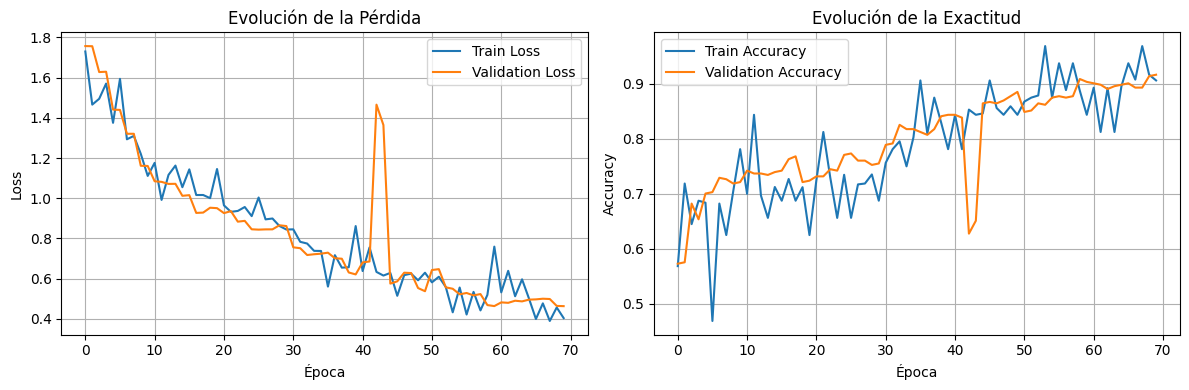

In [ ]:
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Evolución de la Pérdida')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Evolución de la Exactitud')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## 10. Evaluación detallada en Test

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 191ms/step - accuracy: 0.9167 - loss: 0.4557

 Resultados globales en Test:
   Loss: 0.4557
   Accuracy: 0.9167 (91.7%)

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 184ms/step
Reporte de clasificación por clase:
              precision    recall  f1-score   support

 Anthracnose       0.81      0.93      0.87        99
     Healthy       0.95      0.88      0.91       168
        Scab       0.97      0.97      0.97       117

    accuracy                           0.92       384
   macro avg       0.91      0.92      0.92       384
weighted avg       0.92      0.92      0.92       384


 Aciertos por categoría:
   Anthracnose: 92/99 (92.9%)
   Healthy: 147/168 (87.5%)
   Scab: 113/117 (96.6%)


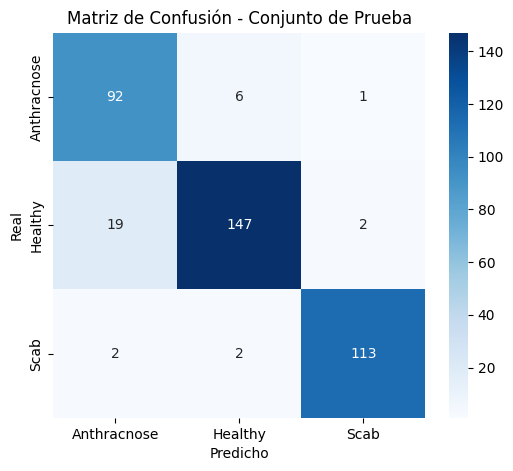

In [ ]:
# Cargar el mejor modelo guardado
model.load_weights('best_model_vgg16.keras')

test_loss, test_acc = model.evaluate(test_gen, steps=len(X_test)//BATCH_SIZE)
print(f"\n Resultados globales en Test:")
print(f"   Loss: {test_loss:.4f}")
print(f"   Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)\n")

# Predicciones completas
y_pred = model.predict(test_gen, steps=len(X_test)//BATCH_SIZE)
y_pred_classes = np.argmax(y_pred, axis=1)

# Reporte por clase
print("Reporte de clasificación por clase:")
print(classification_report(y_test[:len(y_pred_classes)], y_pred_classes, target_names=class_names))

# Conteo de aciertos por categoría
correct_by_class = {}
total_by_class = {}
for true, pred in zip(y_test[:len(y_pred_classes)], y_pred_classes):
    class_name = class_names[true]
    total_by_class[class_name] = total_by_class.get(class_name, 0) + 1
    if true == pred:
        correct_by_class[class_name] = correct_by_class.get(class_name, 0) + 1

print("\n Aciertos por categoría:")
for cls in class_names:
    correct = correct_by_class.get(cls, 0)
    total = total_by_class.get(cls, 0)
    pct = (correct/total)*100 if total>0 else 0
    print(f"   {cls}: {correct}/{total} ({pct:.1f}%)")

# Matriz de confusión
cm = confusion_matrix(y_test[:len(y_pred_classes)], y_pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title('Matriz de Confusión - Conjunto de Prueba')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

## 11. Guardar Modelo Final en .keras

In [ ]:
model.save('modelo_aguacate_vgg16.keras')
!ls -lh modelo_aguacate_vgg16.keras

-rw-r--r-- 1 root root 160M May 26 02:26 modelo_aguacate_vgg16.keras


In [ ]:
# Ruta para guardar el modelo
model_path = '/content/drive/MyDrive/MachineLearning2026/ProyectoMachineLearning/modeloV4_aguacate.keras'

model.save( model_path )

## 12. Prueba con una imagen individual

Real: Anthracnose | Predicción: Anthracnose
Probabilidades: Healthy=0.993, Scab=0.002, Anthracnose=0.006


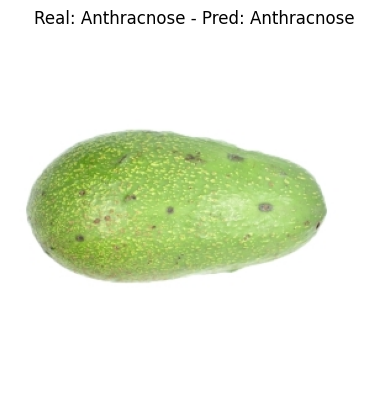

In [ ]:
def predict_image(img_path, model):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    img = img / 255.0
    img_input = np.expand_dims(img, axis=0)
    pred = model.predict(img_input, verbose=0)
    class_idx = np.argmax(pred)
    return class_names[class_idx], pred[0]

sample_img = X_test[15]
true_label = class_names[y_test[15]]
pred_label, probs = predict_image(sample_img, model)
print(f"Real: {true_label} | Predicción: {pred_label}")
print(f"Probabilidades: Healthy={probs[0]:.3f}, Scab={probs[1]:.3f}, Anthracnose={probs[2]:.3f}")

img_display = cv2.cvtColor(cv2.imread(sample_img), cv2.COLOR_BGR2RGB)
plt.imshow(img_display)
plt.title(f"Real: {true_label} - Pred: {pred_label}")
plt.axis('off')
plt.show()